In [1]:
import pandas as pd
from dependencies.PyCEF.cef_minimization import *
import json
import os

In [2]:
from Tools.DatasetTools.GeneralFeaturizer import cn_dict

In [3]:
import matplotlib.pyplot as plt

In [4]:
phases = ['R', 'R_10']#, 'P', 'M', 'delta']

In [5]:
#end_members_atoms = {}
#for phase in phases:
#    end_members_atoms[phase] = pd.read_pickle(f'MoNi/{phase}_guess_structures.pkl')

In [6]:
phases = ['R', 'P', 'M', 'delta', 'R_10']

In [7]:
end_members_atoms={}
for phase in phases : 
    end_members_atoms[phase] = pd.read_pickle(f'Fe-Mo/Atomsobjects/{phase.replace("_10","")}_structures.pkl')
#        'R_10': pd.read_pickle('Fe-Mo/Atomsobjects/R_structures.pkl')

In [8]:
end_member_compositions = {}

In [9]:
def get_compositions(atoms):
    compo = atoms.symbols.formula.count()
    return {e: n/len(atoms)  for e, n in compo.items()}

In [10]:
for phase, phaseatoms in end_members_atoms.items():
    end_member_compositions[phase] = pd.DataFrame.from_dict(phaseatoms.map(get_compositions).to_dict(), orient='index').fillna(0)

In [11]:
end_member_energies = {}

In [12]:
for phase in phases: #, 'P', 'M', 'delta']:
    phase_predictions_file = f'Fe-Mo/results/PREDICTION__{phase.replace("_10", "")}__ACE_lmax=321.csv'
    end_member_energies[phase] = pd.read_csv(phase_predictions_file, header=0, index_col=0)['EF_nmhcp__ACE']
#    end_member_energies[phase] = pd.read_json(phase_predictions_file)
#    with open(phase_predictions_file, 'r') as f: #f'MoNi/results_predictions/{phase}_prediction.json', 'r') as f:
#        this_phase_prediction = json.load(f)
#    end_member_energies[phase] = pd.Series(this_phase_prediction)
#    end_member_energies[phase].name = 'EF'

In [13]:
for phase, phase_energies in end_member_energies.items():
    phase_energies.index = phase_energies.index.str.replace('Fe_pv53.R', 'Fe_pv53.AAAAAAAAAAA')
    phase_energies.index = phase_energies.index.str.replace('Mo_sv53.R', 'Mo_sv53.BBBBBBBBBBB')
    phase_energies.index = phase_energies.index.map(lambda i: i.split('.')[1].replace(f'R-', ''))

In [14]:
end_member_energies['R_10'] = end_member_energies['R_10'][~(end_member_energies['R_10'].index.str.endswith('AB') | end_member_energies['R_10'].index.str.endswith('BA'))]

In [15]:
import re

In [16]:
def redefine_index(theindex):
    if theindex.endswith('AA'):
        return  re.sub('AA$', 'A', theindex)
    if theindex.endswith('BB'):
        return  re.sub('BB$', 'B', theindex)

In [17]:
end_member_energies['R_10'].index.map(redefine_index)

Index(['AAAAAAAAAA', 'AAAAAAAAAB', 'AAAAAAAABA', 'AAAAAAAABB', 'AAAAAAABAA',
       'AAAAAAABAB', 'AAAAAAABBA', 'AAAAAAABBB', 'AAAAAABAAA', 'AAAAAABAAB',
       ...
       'BBBBBBABBA', 'BBBBBBABBB', 'BBBBBBBAAA', 'BBBBBBBAAB', 'BBBBBBBABA',
       'BBBBBBBABB', 'BBBBBBBBAA', 'BBBBBBBBAB', 'BBBBBBBBBA', 'BBBBBBBBBB'],
      dtype='object', length=1024)

In [18]:
pd.concat([pd.Series(end_member_energies['R_10'].index.map(redefine_index)), pd.Series(end_member_energies['R_10'].index)], axis=1)

,0,1
0,AAAAAAAAAA,AAAAAAAAAAA
1,AAAAAAAAAB,AAAAAAAAABB
2,AAAAAAAABA,AAAAAAAABAA
3,AAAAAAAABB,AAAAAAAABBB
4,AAAAAAABAA,AAAAAAABAAA
...,...,...
1019,BBBBBBBABB,BBBBBBBABBB
1020,BBBBBBBBAA,BBBBBBBBAAA
1021,BBBBBBBBAB,BBBBBBBBABB
1022,BBBBBBBBBA,BBBBBBBBBAA


In [19]:
end_member_energies['R_10'].index = end_member_energies['R_10'].index.map(redefine_index)

In [20]:
end_member_energies['R_10']

AAAAAAAAAA    0.168231
AAAAAAAAAB    0.063679
AAAAAAAABA    0.102686
AAAAAAAABB    0.027189
AAAAAAABAA    0.130256
                ...   
BBBBBBBABB    0.318938
BBBBBBBBAA    0.493965
BBBBBBBBAB    0.373295
BBBBBBBBBA    0.451276
BBBBBBBBBB    0.307381
Name: EF_nmhcp__ACE, Length: 1024, dtype: float64

# create per-phase dataset

In [21]:
curated_end_members_energies = {}

In [22]:
for phase, phaseenergies in end_member_energies.items():
    phaseenergies.index = phaseenergies.index.str.replace(f'{phase}-', '')

In [23]:
lattice_names = {
    'R' : ['$b$', '$c_1$', '$f_1$', '$f_2$', '$f_3$', '$f_4$', '$f_5$', '$f_6$', '$f_7$', '$c_2$', '$f_8$'],
    'R_10' : ['$b$', '$c_1$', '$f_1$', '$f_2$', '$f_3$', '$f_4$', '$f_5$', '$f_6$', '$f_7$', '$c_2$ and $f_8$'],
    'delta': ['$a_1$', '$a_2$', '$a_3$', '$a_4$', '$a_5$', '$a_6$', '$a_7$', '$a_8$', '$a_9$', '$a_{10}$', '$a_{11}$', '$a_{12}$', '$a_{13}$', '$a_{14}$'],
    'P': ['$c_1$', '$c_2$', '$c_3$', '$c_4$', '$c_5$', '$c_6$', '$c_7$', '$c_8$', '$c_9$', '$c_{10}$', '$d_1$', '$d_2$'],
    'M': ['$c_1$', '$c_2$', '$c_3$', '$c_4$', '$c_5$', '$c_6$', '$c_7$', '$c_8$', '$c_9$', '$d_1$', '$d_2$']
}

In [24]:
multiplicities = {
    'R': [1,2,6,6,6,6,6,6,6,2,6],
    'R_10':[1,2,6,6,6,6,6,6,6,8],
    'delta': 14*[4],
    'P': 10*[4]+[8,8],
    'M': 9*[4]+[8,8],
} 

In [25]:
multiplicities

{'R': [1, 2, 6, 6, 6, 6, 6, 6, 6, 2, 6],
 'R_10': [1, 2, 6, 6, 6, 6, 6, 6, 6, 8],
 'delta': [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
 'P': [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 8, 8],
 'M': [4, 4, 4, 4, 4, 4, 4, 4, 4, 8, 8]}

In [26]:
DG = {}
for T in [1000, 1250, 1500, 1700, 2000]: #, 2000]:
    DG[T] = {}
    for phase, phaselattice in lattice_names.items():
        if '_10' in phase:
            continue
        print(T, phase)
        DG[T][phase] = {}
        Lattice = LatticeModel(phaselattice, multiplicities[phase])
        xa = np.linspace(0, 1, 20)
        for xA in xa:
            try:
                opt = CEF(latticemodel=Lattice, molar_frac={'A': xA, 'B': 1-xA}, endmember_energies=end_member_energies[phase], temp=T)
                DG[T][phase][xA] = opt.result['y_is']
                DG[T][phase][xA].update({'DG': opt.result['minimized_gibbs_energy (eV/atom)']})
            except Exception as E:
                print (f'could not solve for xa={xA} at T={T} and phase={phase}')
        DG[T][phase]= pd.DataFrame.from_dict(DG[T][phase], orient='index').fillna(0)


1000 R


1000 delta
could not solve for xa=0.42105263157894735 at T=1000 and phase=delta
1000 P
1000 M
1250 R
1250 delta
could not solve for xa=0.3684210526315789 at T=1250 and phase=delta
could not solve for xa=0.42105263157894735 at T=1250 and phase=delta
1250 P
1250 M
1500 R
1500 delta
could not solve for xa=0.3684210526315789 at T=1500 and phase=delta
1500 P
1500 M
1700 R
could not solve for xa=0.5263157894736842 at T=1700 and phase=R
1700 delta
could not solve for xa=0.3684210526315789 at T=1700 and phase=delta
1700 P
1700 M
2000 R
could not solve for xa=0.2631578947368421 at T=2000 and phase=R
2000 delta
2000 P
could not solve for xa=0.8421052631578947 at T=2000 and phase=P
2000 M


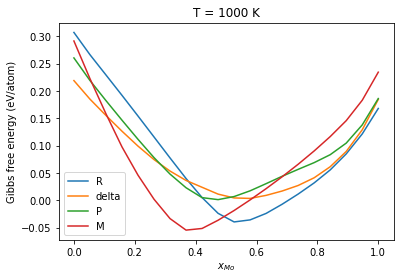

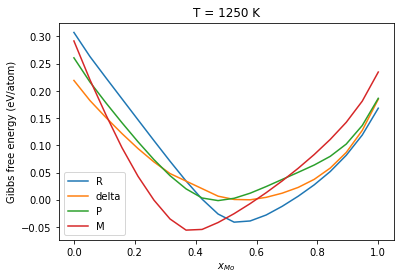

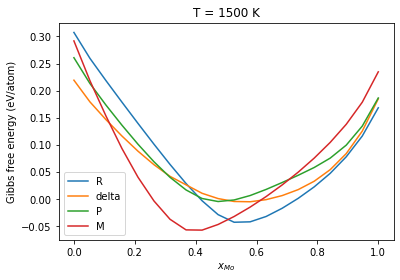

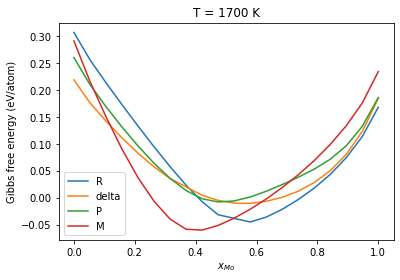

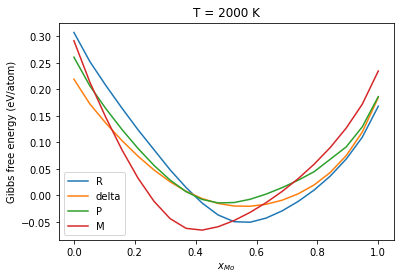

In [36]:
for T, dataT in DG.items():
    if len(dataT) == 0:
        continue
    fig, ax = plt.subplots()
    for phase, thedgs in dataT.items():
        if len(thedgs) == 0:
            continue
        ax.plot(thedgs.index, thedgs['DG'], label=phase)
    ax.legend()
    ax.set_xlabel('$x_{Mo}$')
    ax.set_ylabel('Gibbs free energy (eV/atom)')
    ax.set_title(f'T = {T} K')
    fig.show()

In [37]:
#from prototypemixer.PrototypeTCPs import cn_dict

In [38]:
#unique_cn, indexes = np.unique(cn_dict['P'], return_index=True)

In [39]:
# np.array( cn_dict['P'] )[np.sort(indexes)]

In [40]:
colors={
    '12': 'r',
    '14': 'b',
    '15': 'g',
    '16':  'k',
}

In [41]:
def get_line_color(CN: str):
    for cn, c in colors.items():
        if cn in CN:
            return c
    return 'grey'

In [42]:
#markers = ["1", "2", "3", "4",   0,   1,   2,   3,  4,  5,   6,   7,   8, 'd']
markers = ['>', 'v', '^', '>', 'p', 's', 'P', '*','X','D', 'd', 4, 5, 6]

In [43]:
cn_dict['R_10'] = [z.replace('16a', '16').replace('16b','16') for z in cn_dict['R']]

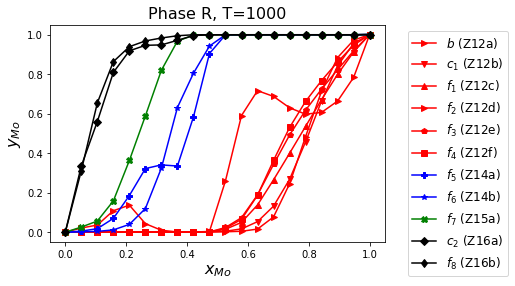

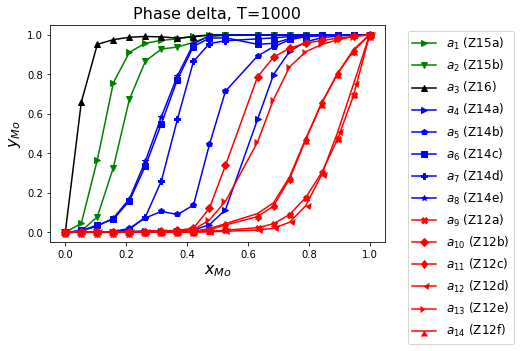

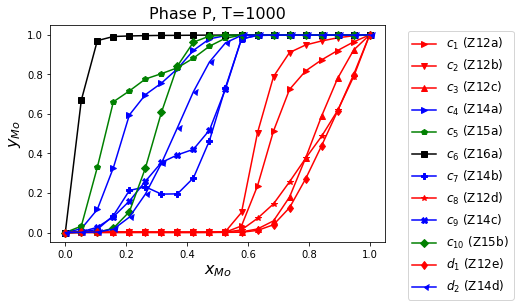

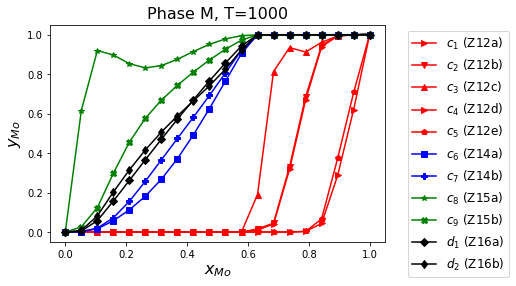

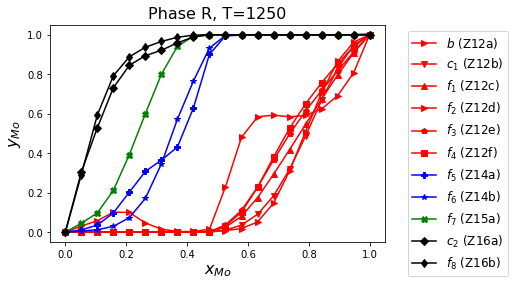

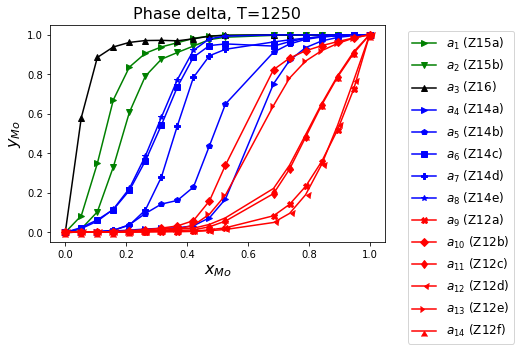

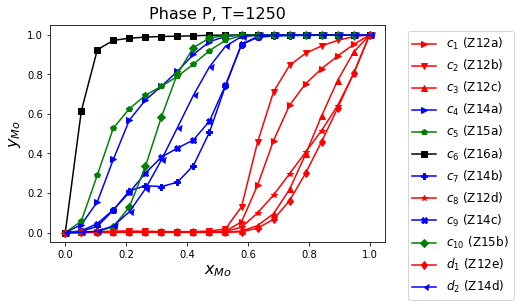

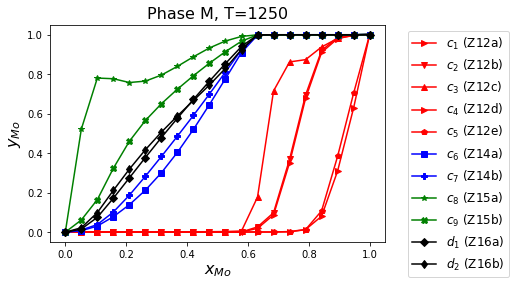

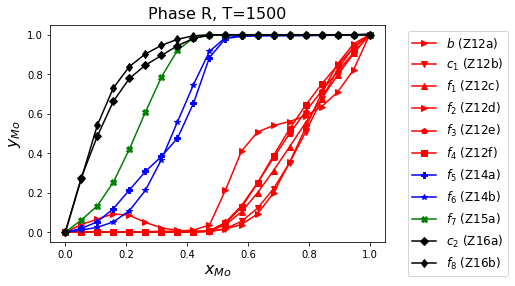

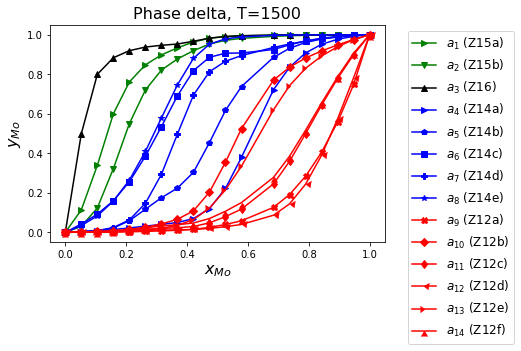

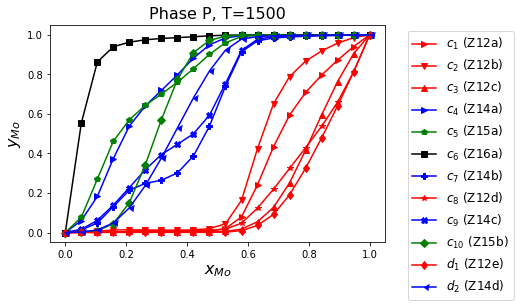

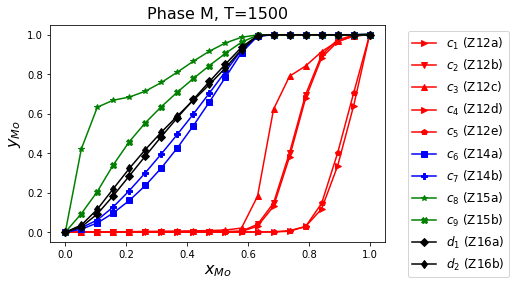

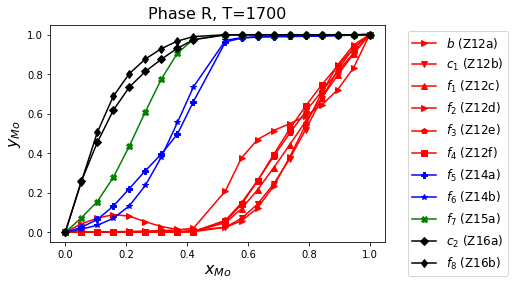

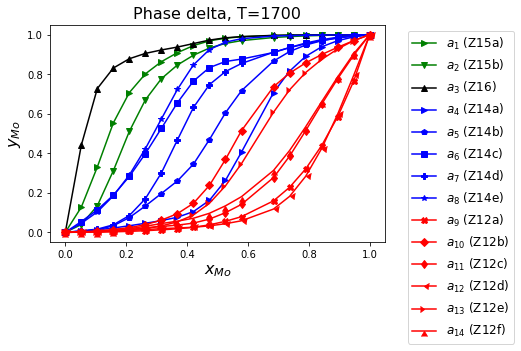

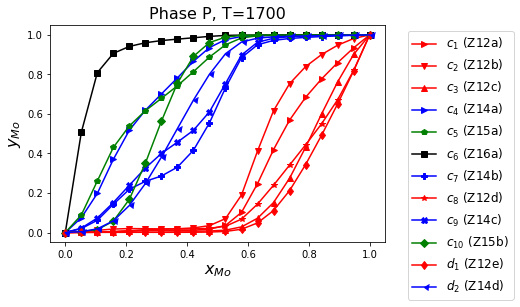

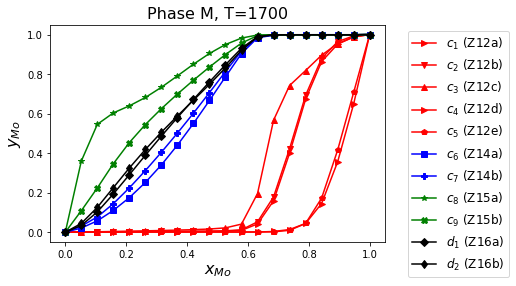

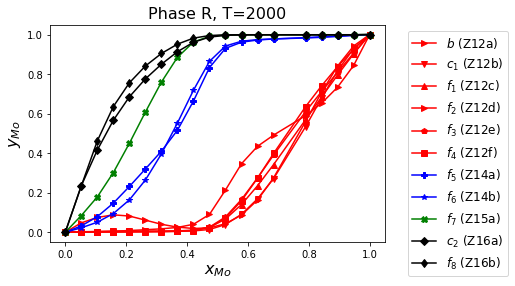

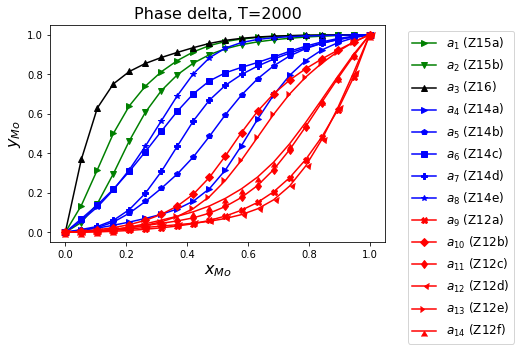

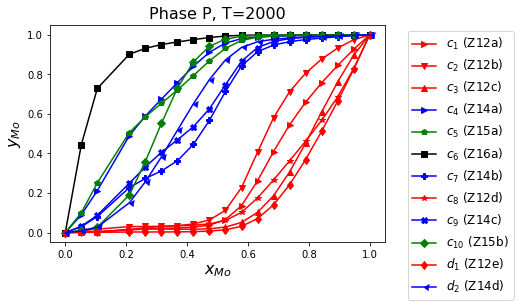

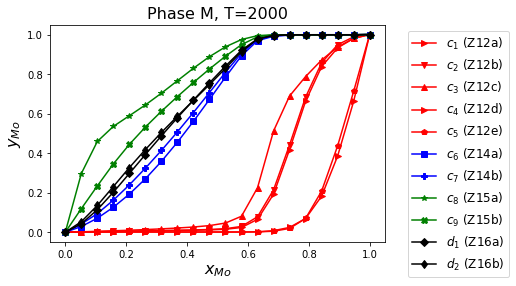

In [44]:
for T, phase_dg in DG.items():
    for phase, dg in phase_dg.items():
        sorted_uinique_cns, indexes = np.unique(cn_dict[phase], return_index=True)
        unique_cns = np.array(cn_dict[phase])[np.sort(indexes)]
        fig, ax = plt.subplots()
        for i, (colname, coldata) in enumerate( dg.filter(regex='A').items()):
            thisc = get_line_color(unique_cns[i])
            ax.plot(1-coldata.index, 1-coldata.values, marker = markers[i], color=thisc, label = f'{colname.replace("A@","")} ({unique_cns[i]})')
        ax.set_ylabel(f'$y_{{Mo}}$', fontsize=16)
        ax.set_xlabel(f'$x_{{Mo}}$', fontsize=16)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
        ax.set_title(f'Phase {phase}, T={T}', fontsize=16)

In [47]:
phase_dg.keys()

dict_keys(['R', 'delta', 'P', 'M'])

In [48]:
for T, phase_dg in DG.items():
    phase = 'R'
    phase_merge = 'R_10'
    dg = phase_dg[phase]
    if 'R_10' not in phase_dg:
        continue
    dgmix = phase_dg['R_10']
    sorted_uinique_cns, indexes = np.unique(cn_dict[phase], return_index=True)
    unique_cns = np.array(cn_dict[phase])[np.sort(indexes)]
    fig, ax = plt.subplots()
    for i, (colname, coldata) in enumerate( dg.filter(regex='A').items()):
        thisc = get_line_color(unique_cns[i])
        ax.plot(1-coldata.index, 1-coldata.values, marker = markers[i], color=thisc, label = f'{colname.replace("A@","")} ({unique_cns[i]})')
    for i, (colname, coldata) in enumerate( dgmix.filter(regex='A').items()):
        thisc = get_line_color(unique_cns[i])
        ax.plot(1-coldata.index, 1-coldata.values, linestyle = '--', color=thisc, label = f'{colname.replace("A@","")} ({unique_cns[i]})') # marker = markers[i],
    ax.set_ylabel(f'$y_{{Mo}}$', fontsize=16)
    ax.set_xlabel(f'$x_{{Mo}}$', fontsize=16)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    ax.set_title(f'Phase {phase}, T={T}', fontsize=16)

# load experimental data

In [49]:
experimentaldata = pd.read_csv('Fe-Mo/ExperimentalData/CrWCo.csv', header=[0], index_col = 0)
experimental_cn = {  'D1': '16','D2':'16','C1':'15','B1':'14','B2':'14','A1':'12','A2':'12','A3':'12','A4':'12','A5':'12','A6':'12'}

In [50]:
experimentaldata.columns

Index(['D1', 'D2', 'C1', 'B1', 'B2', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6'], dtype='object')

In [51]:
experimentaldata.columns

Index(['D1', 'D2', 'C1', 'B1', 'B2', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6'], dtype='object')

In [52]:
experimentaldata_sites_rename={'D1': '$c_2$', 'D2': '$f_8$', 'C1': '$f_7$', 'B1': '$f_5$', 'B2': '$f_6$', 'A1': '$b$', 'A2': '$c_1$', 'A3': '$f_1$', 'A4': '$f_2$', 'A5': '$f_3$', 'A6':'$f_4$'}

In [53]:
experimentaldata.rename(columns=experimentaldata_sites_rename, inplace=True)

In [54]:
experimentaldata

,$c_2$,$f_8$,$f_7$,$f_5$,$f_6$,$b$,$c_1$,$f_1$,$f_2$,$f_3$,$f_4$
composition,,,,,,,,,,,
0.27958,1.00000,1.00000,0.46667,0.37849,0.32258,0.000000,0.000000,0.000000,0.000000,0,0
0.30968,1.00000,0.97204,0.50968,0.42151,0.45806,0.060215,0.049462,0.030108,0.017204,0,0
0.31958,1.00000,1.00000,0.55054,0.41935,0.41935,0.079570,0.079570,0.000000,0.000000,0,0
0.33465,0.93118,0.93118,0.64086,0.49892,0.50968,0.141940,0.040860,0.019355,0.004301,0,0
0.34988,1.00000,0.99570,0.69032,0.55054,0.51828,0.030108,0.019355,0.000000,0.000000,0,0
0.35485,0.99785,0.80860,0.76129,0.51183,0.62796,0.049462,0.040860,0.006452,0.000000,0,0
0.37978,0.99800,0.99800,0.75914,0.62366,0.52903,0.111830,0.107530,0.000000,0.000000,0,0


# compare experimental data to prediction

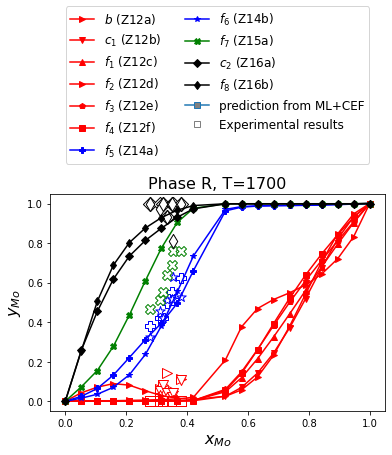

In [ ]:
fig, ax = plt.subplots()
#for site, sitedata in experimentaldata.items():
#    ax.scatter(sitedata.index, sitedata.values, c=colors[experimental_cn[site]])
phase='R'
T=1700
dg=DG[T][phase]
sorted_uinique_cns, indexes = np.unique(cn_dict[phase], return_index=True)
unique_cns = np.array(cn_dict[phase])[np.sort(indexes)]
for i, (colname, coldata) in enumerate( dg.filter(regex='A').items()):
    thisc = get_line_color(unique_cns[i])
    ax.plot(1-coldata.index, 1-coldata.values, marker = markers[i], color=thisc, label = f'{colname.replace("A@","")} ({unique_cns[i]})')
    ax.scatter(experimentaldata.index, experimentaldata[colname.replace('A@', '')], marker = markers[i], s = 100, facecolor='w', edgecolor=thisc, linewidth=1)
#for i, (colname, coldata) in enumerate( dgmix.filter(regex='A').items()):
#    thisc = get_line_color(unique_cns[i])
#    ax.plot(1-coldata.index, 1-coldata.values, linestyle = '--', color=thisc)#, label = f'{colname.replace("A@","")} ({unique_cns[i]})') # marker = markers[i],
handles, labels = ax.get_legend_handles_labels()
#handles.append(Line2D([],[],linestyle='--')),
handles.append(Line2D([],[],marker='s', markerfacecolor = 'grey'))
handles.append(Line2D([],[],marker='s', markerfacecolor = 'white', color='grey', linewidth=5, linestyle=''))

#labels.append('10 sublattice model')
labels.append('prediction from ML+CEF')
labels.append('Experimental results')
ax.set_ylabel(f'$y_{{Mo}}$', fontsize=16)
ax.set_xlabel(f'$x_{{Mo}}$', fontsize=16)
ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.5), loc='center', fontsize=12, ncols = 2)
ax.set_title(f'Phase {phase}, T={T}', fontsize=16)
ax.asp
fig.savefig('Fe-Mo/graphs/SiteOccupancyExperimental_vs_Predictions.pdf')


In [57]:
from matplotlib.lines import Line2D

In [56]:
labels

['$b$ (Z12a)',
 '$c_1$ (Z12b)',
 '$f_1$ (Z12c)',
 '$f_2$ (Z12d)',
 '$f_3$ (Z12e)',
 '$f_4$ (Z12f)',
 '$f_5$ (Z14a)',
 '$f_6$ (Z14b)',
 '$f_7$ (Z15a)',
 '$c_2$ (Z16a)',
 '$f_8$ (Z16b)',
 '10 sublattice model',
 'prediction from ML+CEF',
 'Experimental results']